In [ ]:
%pip install matplotlib numpy opencv-python

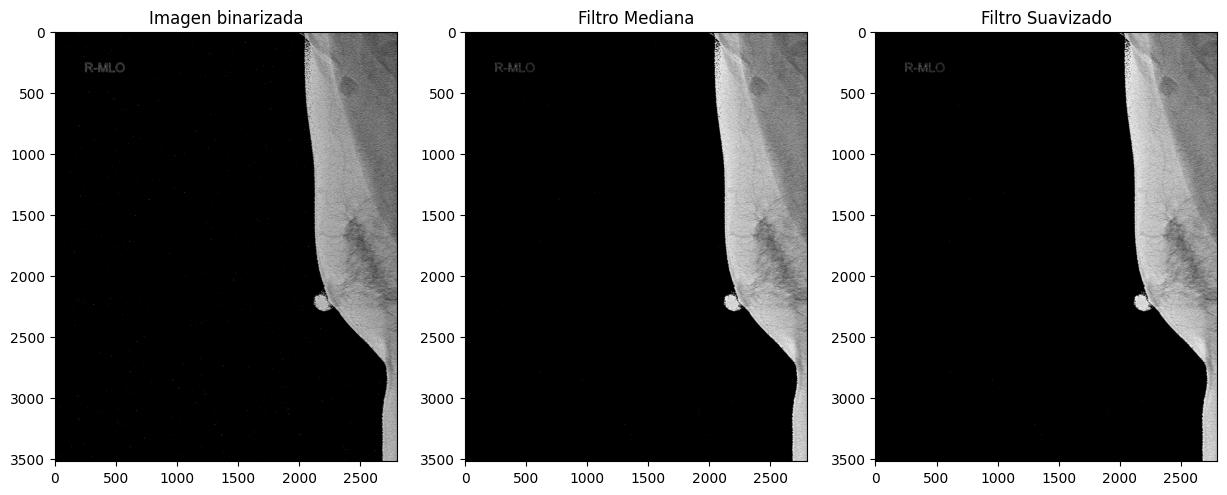

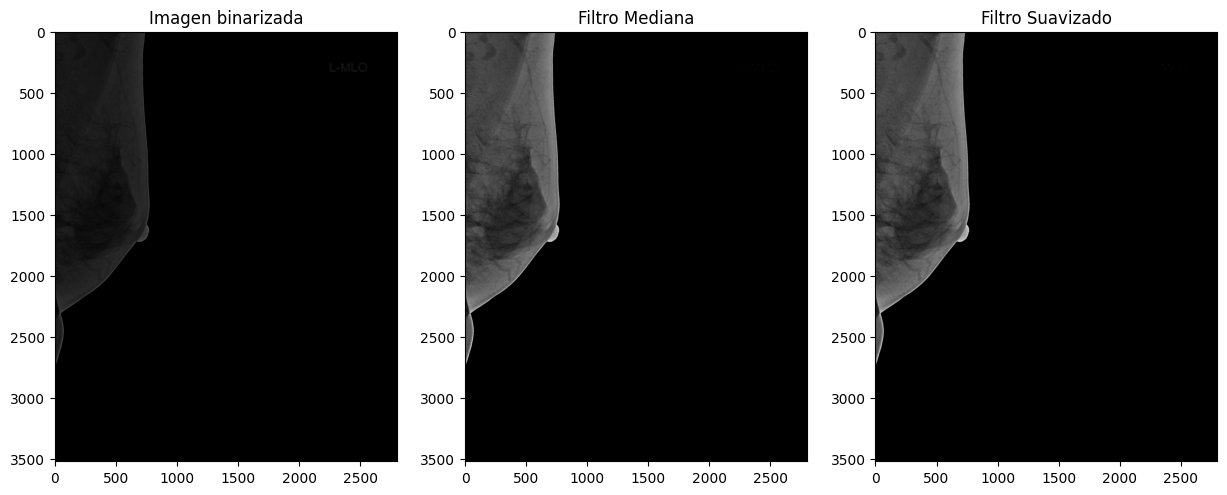

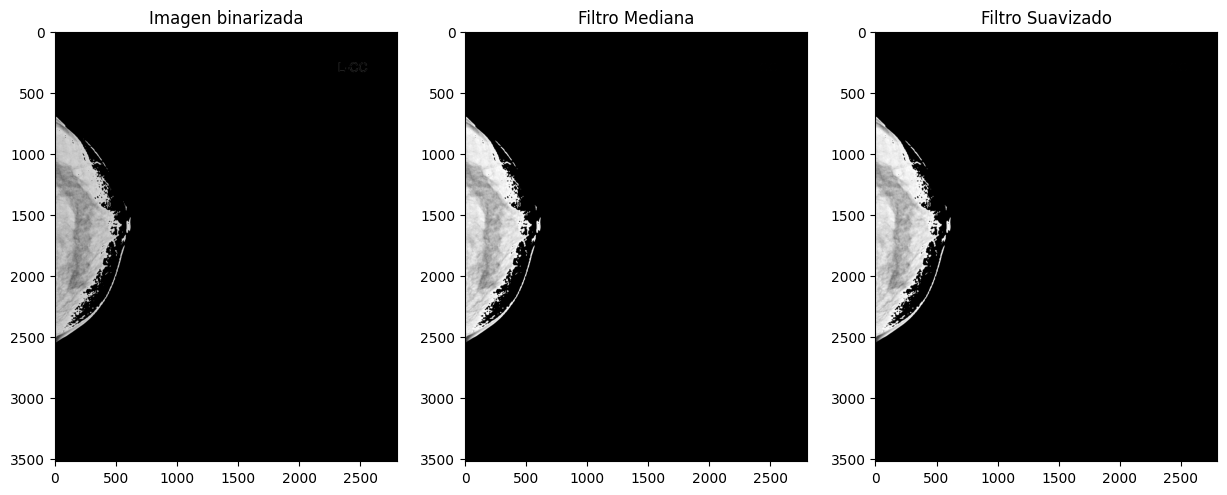

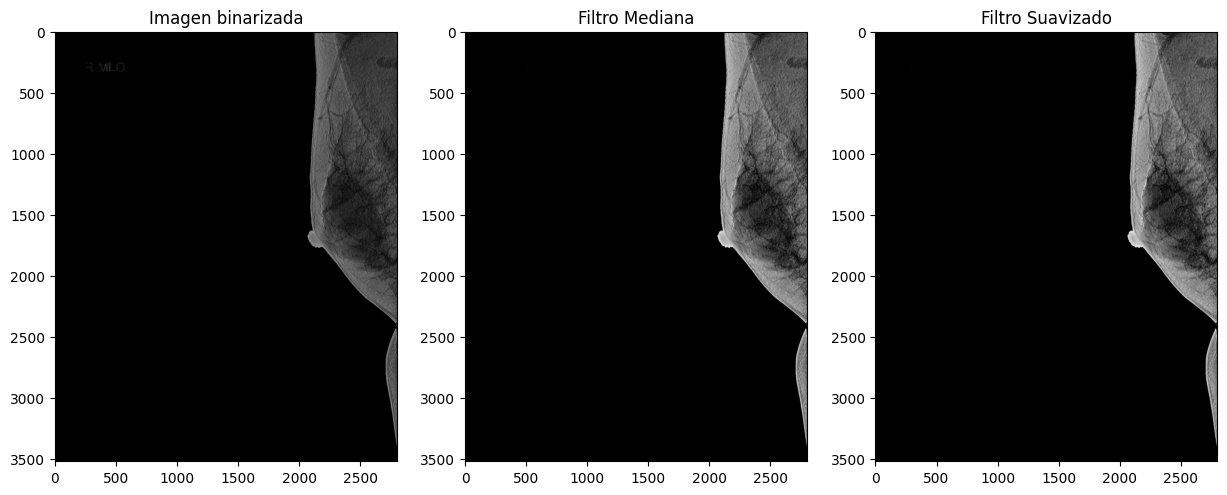

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

def listdir(path):
    return [os.path.join(path, file) for file in os.listdir(path)]

images = [(cv2.imread(image_path), image_path) for image_path in listdir('./img')]

filters = {
    0: ['OTSU', 'MEDIAN', 'KERNEL'],
    1: ['OTSU', 'MEDIAN', 'KERNEL'],
    2: ['OTSU', 'MEDIAN', 'KERNEL'],
    3: ['OTSU', 'MEDIAN', 'KERNEL'],
}

def preprocess(img, path):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5, 5), cv2.BORDER_DEFAULT)
    ret3, th3 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    img = gray * (th3 // 255)

    # Filtro con la mediana
    median_smooth = cv2.medianBlur(img, 5)

    # Filtro con convolución
    kernel = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16
    mean_smooth = cv2.filter2D(median_smooth, -1, kernel)

    os.makedirs("./out", exist_ok=True)
    cv2.imwrite(f"./out/{os.path.basename(path)}", mean_smooth)

    plt.figure(figsize=(15, 15))
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Imagen con Suavizado de OTSU")

    plt.subplot(1, 3, 2)
    plt.imshow(median_smooth, cmap="gray")
    plt.title("Filtro Mediana")

    plt.subplot(1, 3, 3)
    plt.imshow(mean_smooth, cmap="gray")
    plt.title("Filtro Suavizado")

    plt.show()

for img, path in images:
    preprocess(img, path)
